# Example 2 -- Cubic phase gate injection

This notebook builds a CV-ZX diagram from scratch, simplifies it rule by rule (so you can see what each rewrite rule does), and then compares that against running the fully automated `optimize()` pipeline.

**The physical setup.** A non-Gaussian ancilla mode -- a `QSpider` state carrying a cubic phase term `gamma * x^3`, which has no Gaussian (beamsplitter/squeezer/displacement) equivalent -- is coupled to the input mode through a two-mode entangling gate. The ancilla side is then homodyne-measured, producing a classical outcome `m`, and a correction gate (whose parameter depends on `m`) is applied to the surviving mode -- "feedforward": a later gate's parameter is computed from an earlier measurement's outcome, rather than being fixed in advance.

**The claim we're checking.** This gadget -- prepare a cubic-phase ancilla, entangle, measure, feedforward-correct -- teleports the ancilla's non-Gaussian phase onto the input mode using only measurement and (Gaussian) linear optics. The paper's claim: the whole gadget reduces to a single cubic phase gate, `QSpider(1, 1, gamma*x^3)`, acting on the input mode -- i.e. a genuinely non-Gaussian gate was applied to the input without ever needing a genuinely non-Gaussian *operation* on it directly.

This example is also the worked case that motivated `TerminalAbsorptionRule`'s newest sub-case: absorbing a state that sits directly inside a `ContractedDiagram` (rather than only a standalone leaf next to it). The "3. `TerminalAbsorptionRule`" step below is exactly that sub-case firing.

**New to CV-ZX calculus / this codebase?** A few terms that come up throughout:
- **`QSpider`/`PSpider`** -- the two families of "spiders" (generalized nodes) the calculus is built from, one per quadrature basis (position/momentum). Each carries a polynomial *phase* (a `ZxPoly`) and can have any number of input/output wires.
- **`ZxPoly`** -- a real polynomial (in one variable) used as a spider's phase, e.g. `ZxPoly({3: 1.0})` is `x^3`. A spider with the all-zero polynomial (`ZxPoly({})`) and exactly one input/output is the calculus's identity wire. A phase's constant (degree 0) term is always an unobservable global phase, so `QSpider`/`PSpider` drop it automatically at construction.
- **`TensorDiagram`** -- diagrams placed side by side (in parallel), like `⊗` in tensor-network notation.
- **`CompositionDiagram`** -- diagrams chained one after another (in sequence), like `∘`.
- **`ContractedDiagram`** -- two diagrams wired together with some connections kept external and others fed back internally (Eq. 51 of the paper) -- the general mechanism a multi-mode gate's spider decomposition is built from. Unlike the squeezer example (which gets its `ContractedDiagram` from `BeamsplitterGate(...).expand()`), this example builds one directly by hand, below.
- A rewrite **rule** looks for a specific local pattern in a diagram and replaces it with something simpler representing the same physical operation -- see the rule-by-rule walkthrough below.

In [1]:
from sympy import symbols

# Diagram building blocks -- QSpider/PSpider (the two spider colors), ZxPoly
# (polynomial phases), TensorDiagram/CompositionDiagram (parallel/sequential
# composition), and ContractedDiagram (Eq. 51 of the paper -- two diagrams
# wired together, some connections external and some fed back internally).
from cvzx.ir.base import CompositionDiagram, ContractedDiagram, PSpider, QSpider, TensorDiagram, ZxPoly
from cvzx.passes.optimize import optimize
from cvzx.passes.normalize import normalize_diagram
from cvzx.visualization.core import visualize

# The zero-phase (trivial) polynomial -- used below for identity wires and the
# entangling gate's own spiders, both of which are "no phase" spiders.
zero_phase = ZxPoly({})

## Build the diagram

We build the gadget directly as a `Diagram` (rather than starting from a circuit description) so we can see exactly how each physical step maps onto CV-ZX pieces. It has three stages, composed in sequence:

- **Stage 0**: the input mode -- a bare identity wire, `QSpider(1, 1, zero_phase)` -- tensored (placed side by side) with the cubic-phase ancilla, `QSpider(0, 1, gamma*x^3, ...)` (a state: no inputs, one output).
- **Stage 1**: the two-mode entangling gate coupling the input mode to the ancilla, built directly as a `ContractedDiagram(QSpider(2, 1, 0), PSpider(1, 2, 0), I1=[], I2=[], J1=[1], J2=[0])`: `first` is a zero-phase `QSpider` with 2 inputs/1 output, `second` a zero-phase `PSpider` with 1 input/2 outputs, tied together by a single *feedback* wire (`J1=[1]`, `J2=[0]`) -- `second`'s output 0 feeds back into `first`'s input 1. What stays external: `first`'s input 0 / output 0 (the mode we care about, straight through this stage) and `second`'s input 0 / output 1 (the ancilla comes in on the former, the entangled result goes on to stage 2 via the latter).
- **Stage 2**: the ancilla side is measured (`meas`, a `PSpider(1, 0, ...)` effect -- one input, zero outputs, so it "consumes" that mode and produces a classical outcome we call `m`); the other output receives a correction gate (a raw `QSpider(1, 1, ...)`, not one of the named compact gate classes) whose phase is `feedforward`-derived from `m`.

**Feedforward bookkeeping.** `meas.id` is the CV-ZX graph's unique node id for the measurement leaf. The correction gate is built with `parametric=True`, `feedforward=True`, `measurement_ids={meas.id}`, and `param_measurement_map={m: {meas.id}}` -- this is how the diagram records *which* measurement a later gate's parameter depends on, so later rewriting can correctly account for that dependency instead of treating the gate as if its parameter were already known.

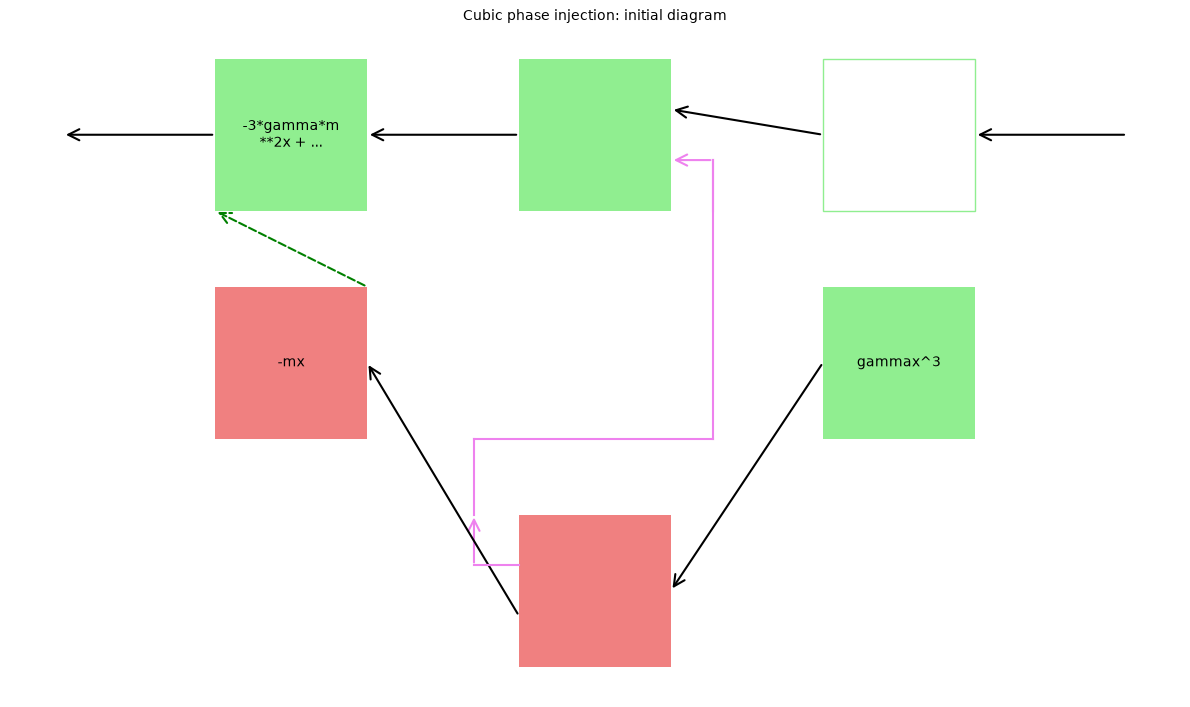

In [2]:
m, gamma = symbols("m gamma", real=True)

# The measurement effect: a PSpider with one input, zero outputs (an "effect",
# the dual of a state). Its phase -m*x records that its outcome is called m.
meas = PSpider(1, 0, ZxPoly({1: -m}), True)

# Stage 0: input mode (identity wire) tensored with the cubic-phase ancilla state.
stage0 = TensorDiagram([
    QSpider(1, 1, zero_phase),
    QSpider(0, 1, ZxPoly({3: gamma}), True),
])

# Stage 1: the two-mode entangling gate, built directly as a ContractedDiagram
# (see the markdown above for exactly how its wires connect).
stage1 = ContractedDiagram(QSpider(2, 1, zero_phase), PSpider(1, 2, zero_phase), [], [], [1], [0])

# Stage 2: measure the ancilla side; feedforward-correct the surviving mode
# with a phase whose coefficients depend on the measurement outcome m.
stage2 = TensorDiagram([
    QSpider(
        1, 1,
        ZxPoly({1: -3 * gamma * m**2, 2: 3 * gamma * m}),
        True,               # parametric: the correction's phase is symbolic
        True,               # feedforward: this gate's phase depends on an earlier measurement
        {meas.id},          # measurement_ids: which measurement(s) it depends on
        {m: {meas.id}},     # param_measurement_map: symbol -> measurement id(s)
    ),
    meas,
])

# Stages 0-1-2 in sequence make up the full gadget.
gadget = CompositionDiagram([stage0, stage1, stage2])
fig_gadget = visualize(gadget, "Cubic phase injection: initial diagram")

### Sanity check: one mode in, one mode out

The gadget consumes a fresh ancilla and a measurement outcome internally, but from the *outside* it should still look like a single-mode gate: one input wire (the mode receiving the cubic phase) and one output wire (the same mode, non-Gaussian phase applied). Let's confirm that directly from the diagram's own arity before doing any simplification.

In [3]:
print(f"gadget: {gadget.num_inputs} input(s) -> {gadget.num_outputs} output(s)")

gadget: 1 input(s) -> 1 output(s)


## The paper's claimed reduced form

The paper's claim is that the whole gadget above -- cubic-phase ancilla, entangling gate, measurement, feedforward correction -- is equivalent to a single cubic phase gate acting on the input mode, with no leftover dependence on the measurement outcome `m` at all. We build that claimed target here so we have something to visually compare the simplified gadget against, below.

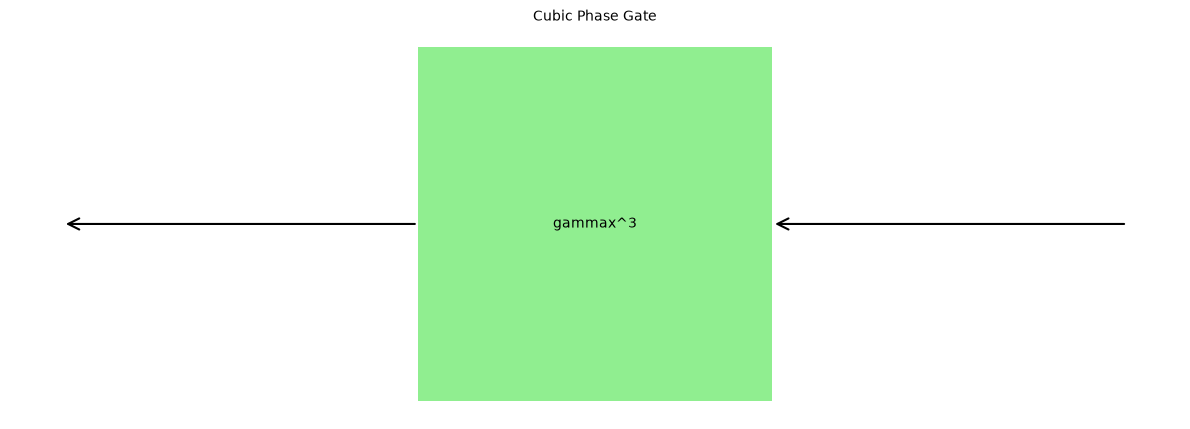

In [4]:
# The paper's claimed closed-form equivalent -- for visual comparison only.
target_diagram = QSpider(1, 1, ZxPoly({3: gamma}), True)
fig_target = visualize(target_diagram, "Cubic Phase Gate")

## Run the optimization pipeline incrementally

Simplifying `gadget` down to a single cubic phase gate requires several rewrite rules, each targeting a different local pattern. `assume_infinite_squeezing=True` is required throughout: the ancilla and the measurement above are only meaningful as *idealized* (infinite-squeezing) eigenstates, and it's exactly that idealized regime that `TerminalAbsorptionRule`'s cross-color sub-cases rely on to apply at all.

We'll run the rewrite rules one at a time below, visualizing the diagram after each one, so you can see exactly what each rule changes. Each rule works the same way: `rule.match(graph)` looks for its pattern in the graph (returning an empty list if nothing matches) and `rule.apply_rule(graph)` rewrites every match it finds, in place.

Afterwards we'll run the `optimize()` function, which repeats this whole process automatically -- including *multiple rounds* of it, since simplifying one part of the diagram can expose further simplifications elsewhere -- until nothing changes any more.

In [5]:
from cvzx.backends.nx.rules import TerminalAbsorptionRule, FusionRule, ChainReductionRule
from cvzx.backends.nx.graph import to_diagram, to_graph

### 1. `FusionRule`

`FusionRule` merges two adjacent, same-color spiders connected by a single wire into one spider, adding their phases together. Here, `meas` (stage 2's measurement effect, a `PSpider`) is directly composed into `second` -- the entangling gate's own `PSpider` child from stage 1 -- so this fuses `meas` straight into `second`, replacing its old slot in stage 2 with a `VoidDiagram` placeholder.

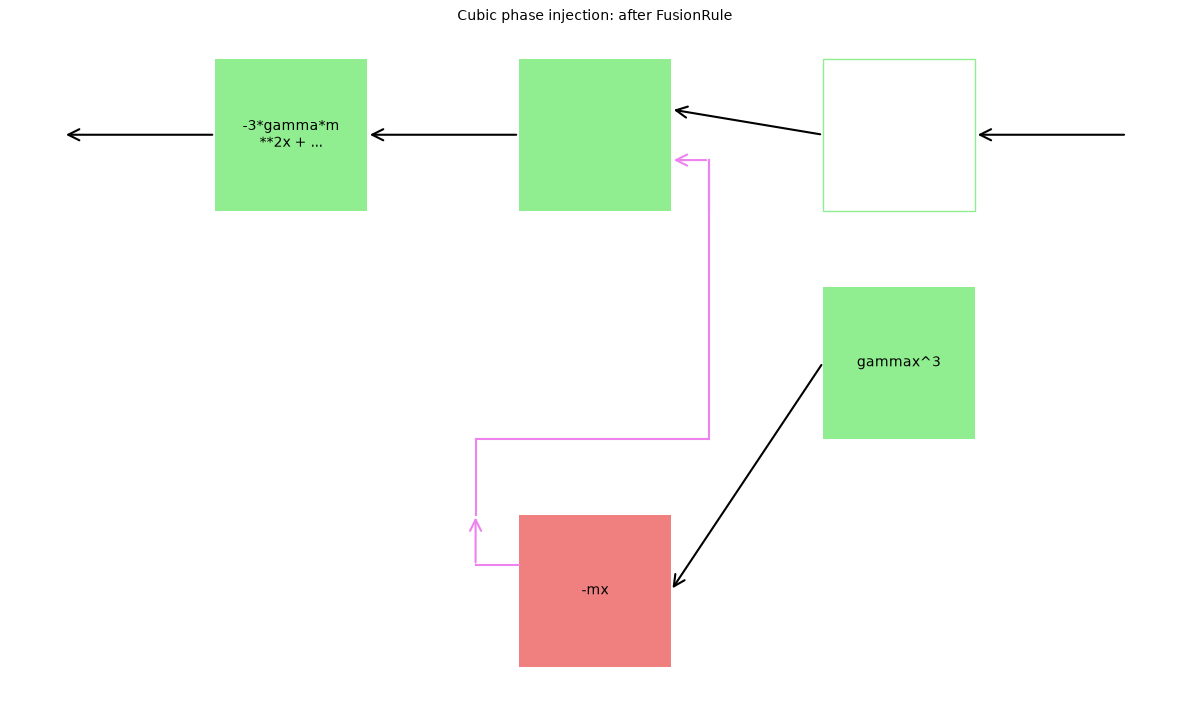

In [6]:
fusion_rule = FusionRule()
graph_after_fusion = to_graph(gadget)
fusion_rule.apply_rule(graph_after_fusion)

diag_after_fusion = to_diagram(graph_after_fusion)
fig_after_fusion = visualize(diag_after_fusion, "Cubic phase injection: after FusionRule")

### 2. `TerminalAbsorptionRule`

`TerminalAbsorptionRule` absorbs a gate sitting right next to a *terminal* -- a spider with arity `(1, 0)` (an effect) or `(0, 1)` (a state, like our cubic-phase ancilla) -- directly into that terminal's own phase, eliminating the gate. This example needs its newest sub-case: the ancilla terminal is composed directly into `second` (the entangling gate's `PSpider`, now carrying `meas`'s folded-in phase `-m*x` after the fusion above) -- and `second` is itself a direct child of the `ContractedDiagram`, not a standalone leaf. Since `second` has exactly one internally-consumed port (the feedback wire to `first`) and its only other port already leads to a `VoidDiagram`, the ancilla terminal can absorb it wholesale.

Since the ancilla (`QSpider`) and `second` (`PSpider`) are opposite colors, this is the cross-color case: `second`'s phase `-m*x` is degree 1 (`a = -m`), so the ancilla's phase `f(x) = gamma*x^3` folds into `f(x + a) = gamma*(x - m)^3`. The ancilla terminal then takes over `second`'s exact slot in the contraction (same as `second`'s old shape: 0 inputs, 1 output), and the ancilla's own old slot in stage 0 becomes a `VoidDiagram`. (`f(x-m)^3` expands to `gamma*x^3 - 3*gamma*m*x^2 + 3*gamma*m^2*x - gamma*m^3`, but that trailing `-gamma*m^3` is a constant term -- an unobservable global phase -- so `QSpider` drops it automatically when the diagram below gets rebuilt.)

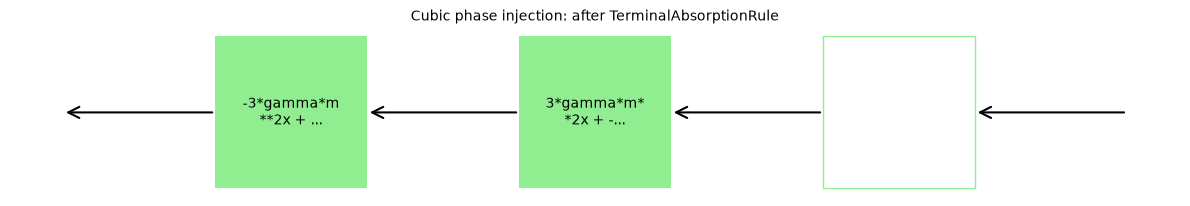

In [7]:
absorption_rule = TerminalAbsorptionRule(True)
graph_after_absorption = to_graph(diag_after_fusion)
absorption_rule.apply_rule(graph_after_absorption)

diag_after_absorption = to_diagram(graph_after_absorption)
fig_after_absorption = visualize(diag_after_absorption, "Cubic phase injection: after TerminalAbsorptionRule")

### 3. `FusionRule`, again

Absorbing the ancilla into `second` made `first` and `second` the *same* color (both `QSpider` now) -- exactly the shape `FusionRule` also fuses, via its other matching mode (the two halves of a `ContractedDiagram` coupled through its `I1`/`I2`/`J1`/`J2` wiring). That collapses the entire `ContractedDiagram` into one flat spider, adding the phases: `first`'s zero phase plus the absorbed terminal's `gamma*x^3 - 3*gamma*m*x^2 + 3*gamma*m^2*x`.

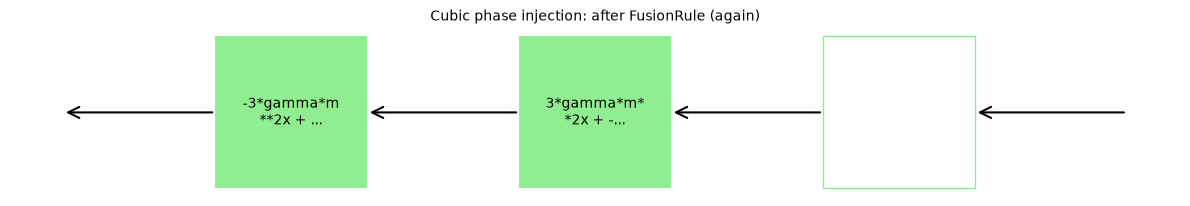

In [8]:
fusion_rule_again = FusionRule()
graph_after_fusion2 = to_graph(diag_after_absorption)

matches = fusion_rule_again.match(graph_after_fusion2)

fusion_rule_again.apply_rule(graph_after_fusion2)

diag_after_fusion2 = to_diagram(graph_after_fusion2)
fig_after_fusion2 = visualize(diag_after_fusion2, "Cubic phase injection: after FusionRule (again)")

### 4. `ChainReductionRule`

`ChainReductionRule` isn't just for the named compact gate classes (`PhaseRotationGate`, `SqueezingGate`, ...) -- it also reduces two adjacent same-color raw spiders directly, `Q(u(x)) . Q(v(x)) -> Q((u+v)(x))`, any degree, no restriction. The diagram now has exactly that shape: the just-fused spider (`gamma*x^3 - 3*gamma*m*x^2 + 3*gamma*m^2*x`) sits directly next to the leftover correction gate (`3*gamma*m*x^2 - 3*gamma*m^2*x`) from stage 2. Their phases were engineered to cancel: adding them leaves exactly `gamma*x^3`, with every `m`-dependent term gone -- the whole point of the feedforward correction.

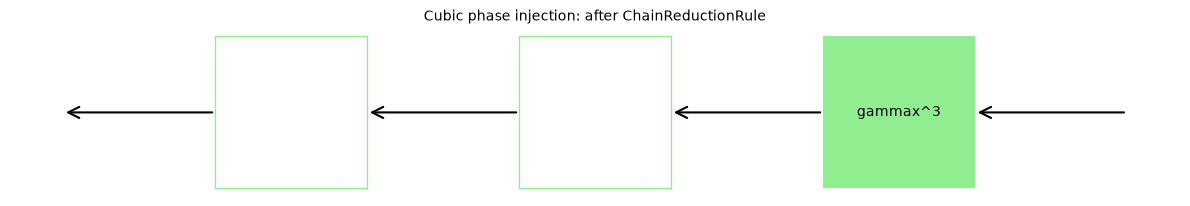

In [9]:
chain_reduction_rule = ChainReductionRule()
graph_after_chain_reduction = to_graph(diag_after_fusion2)
chain_reduction_rule.apply_rule(graph_after_chain_reduction)

diag_after_chain_reduction = to_diagram(graph_after_chain_reduction)
fig_after_chain_reduction = visualize(diag_after_chain_reduction, "Cubic phase injection: after ChainReductionRule")

## Tidy up the picture

The rules above leave some `VoidDiagram` filler and container nesting behind (bookkeeping placeholders for slots that got consumed along the way). `normalize_diagram` rewrites the diagram into a canonical, alternating form purely for a cleaner picture -- it doesn't do any further algebraic simplification.

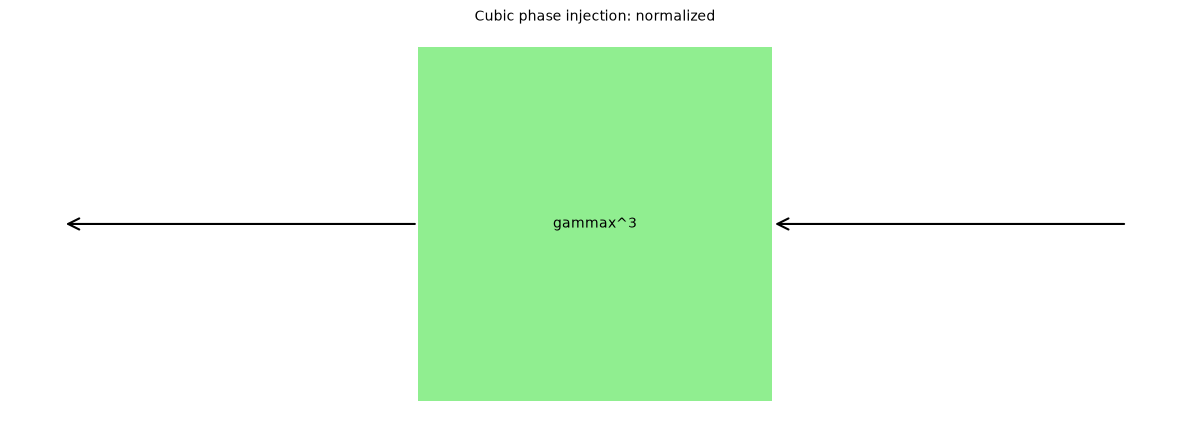

In [10]:
diag_normalized = normalize_diagram(diag_after_chain_reduction)
fig_normalized = visualize(diag_normalized, "Cubic phase injection: normalized")

This is the paper's claimed shape -- a single cubic phase gate, `gamma*x^3`, with no leftover `m`-dependence anywhere. Compare the picture above to `fig_target` (the paper's claimed shape) a few cells up.

## Now let's run the optimization pipeline

Doing this one rule at a time, one pass each, is useful for seeing what's happening -- but in practice you'd just call `optimize()`. It runs every rule (in a fixed order tuned so each one feeds the next) to a fixed point, and repeats that over multiple rounds -- since simplifying part of the diagram in one round can expose further simplifications only visible in the next -- until nothing changes any more.

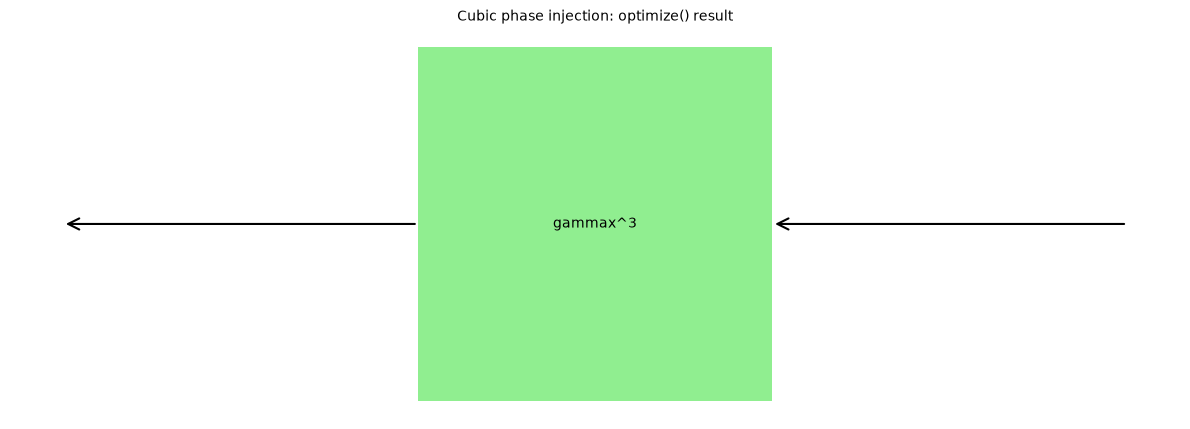

In [11]:
from cvzx.config import Backend  # lets you pick the graph backend, e.g. optimize(..., backend=Backend.RX)

result = optimize(gadget, backend=Backend.NETWORKX, assume_infinite_squeezing=True)
fig_optimized = visualize(normalize_diagram(result.diagram), "Cubic phase injection: optimize() result")

`optimize()` reaches the same fixed point as the rule-by-rule walkthrough above -- unsurprising here, since this gadget only needed one round to fully simplify -- but it's the version you'd actually use day to day.

## Benchmarking the reduction

The pictures above make it clear `optimize()` produced something much simpler than `gadget` -- but "simpler" can be made precise. `cvzx.utils.metrics.compare_metrics` measures exactly how much smaller a diagram got, across several independent axes: spider/gate/generator counts (the ones that matter most -- see the dev guide's "Benchmarking optimization quality" page, `docs/source/dev_guide/benchmarks.md`, for why bookkeeping leaves like identity wires and `VoidDiagram` placeholders are deliberately excluded from these), raw node/edge totals, a non-Clifford-analogue phase count, and stage depth.

In [12]:
from cvzx.utils.metrics import compare_metrics

comparison = compare_metrics(gadget, result.diagram)

print(f"{'metric':<20s}{'before':>8s}{'after':>8s}{'reduction':>12s}")
for field in ("spiders", "gates", "generators", "nodes", "edges", "non_clifford_phases", "depth"):
    before = getattr(comparison.before, field)
    after = getattr(comparison.after, field)
    reduction = comparison.reduction(field)
    reduction_str = f"{reduction:.0%}" if reduction is not None else "n/a"
    print(f"{field:<20s}{before!s:>8s}{after!s:>8s}{reduction_str:>12s}")

metric                before   after   reduction
spiders                    5       1         80%
gates                      0       0         n/a
generators                 5       1         80%
nodes                     10       8         20%
edges                      5       2         60%
non_clifford_phases        1       1          0%
depth                   None       1         n/a


`spiders`/`generators`/`nodes`/`edges` all drop sharply: `optimize()` genuinely eliminates the ancilla and the measurement effect. `non_clifford_phases` stays flat at 1 -- there was never a way to make that go to zero, since the whole point of the gadget is to *apply* a genuinely non-Gaussian (cubic phase) gate, not remove one; the count just confirms it's exactly one gate's worth, not smeared across several. `depth` goes from undefined to a well-defined `1`: `gadget` still contains a `ContractedDiagram` (from stage 1), and `normalize_diagram` -- which `depth` is measured via -- conservatively leaves any `ContractedDiagram` unchanged rather than guessing a stage count for it; `result.diagram` has no such container left.